In [2]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange


# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import QUALITATIVE_TRAIN_PATHS, QUALITATIVE_TEST_PATHS, LAPIS_TEST_PATHS, TRAIN_PATHS, TEST_PATHS
from settings.expresions import FACIAL_EXPRESSION_NAMES

In [3]:
tf.__version__

'2.14.0-rc1'

In [4]:
TRAIN = True  # Flag to enable model training
TEST = True  # Flag to enable model testing/evaluation
TEST_VIDEO = False  # Flag for testing with entire videos (vs. single frames)
PLOT = False  # Flag to generate visual plots during training
SAVE_GIFS = False  # Flag to save results as GIFs for visualization
TEST_DEFORMATIONS = False  # Flag to test the deformation process separately 
SAVE_GIFS_SIMILAR = False  # Flag to save GIFs of similarity measures (likely for analysis)
SAVE_GIFS_LAPIS_TEST = False  # Likely a flag for a specific testing dataset ('LAPIS')
QUALITATIVE = False  # Flag to switch between qualitative vs. quantitative output modes

# Loss Functions
COHERENCE_LOSS = l1_loss  # Loss for maintaining temporal smoothness between frames 
TARGET_PREDICTED_LOSS = l1_loss  # Loss when model tries to directly predict target image
LANDMARKS_LOSS = pairwise_loss  # Loss for predicted facial landmark positions
LANDMARKS_COHERENCE_LOSS = pairwise_loss  # Loss for landmark consistency across frames
INTERPOLATION_FRAMES_LOSS = l1_loss  # Loss for intermediate frames generated during motion interpolation
INTERPOLATION_LANDMARKS_LOSS = None  # No direct loss on interpolated landmarks (may rely on other losses)

BLEND_DEFORMATIONS = True  # Flag to blend deformed images with the source (for smoother results)

# Image and Data Dimensions
r = 256  # Base resolution for images
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3  # Image has 3 color channels (RGB)

N_LANDMARKS = 68  # Number of facial landmarks used by the model
BATCH_SIZE = 10  # Number of images/frames processed in a single training step
STEPS = 127475  # Total training steps (adjust based on your dataset size)
STEPS = STEPS // BATCH_SIZE  # Ensure integer steps for batching
SAVING_EACH_STEPS = 50  #  Frequency to save model checkpoints
DISPLAY_EACH_STEPS = 15  # Frequency to display training progress
N_TESTING_FRAMES = 9600  # Number of frames to use for testing/evaluation

# Loss Weights (Control the relative importance of each loss term)
LAMBDA_TARGET_PREDICTED_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = 100  # This suggests an additional perceptual loss
LAMBDA_INTERPOLATION_FRAMES_LOSS = 100
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

# File Paths 
VIDEOS_FOLDER = f'mug{r}'  # Folder containing video data 
BASE_PATH = Path('../')  # Base directory of the project
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
if QUALITATIVE:
    OUTPUT_PATH = APP_PATH / 'qualitative_output'  # Output for qualitative results
else:
    OUTPUT_PATH  = APP_PATH / 'quantitative_output'  # Output for numerical metrics


default_dimension = "mug128" 

In [5]:
id_string = f"b{BATCH_SIZE}_r{r}_"
if TARGET_PREDICTED_LOSS:
    id_string += f"f1_{TARGET_PREDICTED_LOSS.__name__}_{LAMBDA_TARGET_PREDICTED_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100'

In [6]:
OUTPUT_MEDIA_FOLDER = OUTPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

In [7]:
log_dir = OUTPUT_MEDIA_FOLDER / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

## Load the dataset

In [8]:
if QUALITATIVE:
    train_paths = QUALITATIVE_TRAIN_PATHS  # Select dataset paths for qualitative analysis
    test_paths = QUALITATIVE_TEST_PATHS
else:
    train_paths = TRAIN_PATHS  # Select dataset paths for standard quantitative evaluation
    test_paths = TEST_PATHS 

In [9]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [10]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2024-01-11 23:22:27.310945: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13514 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


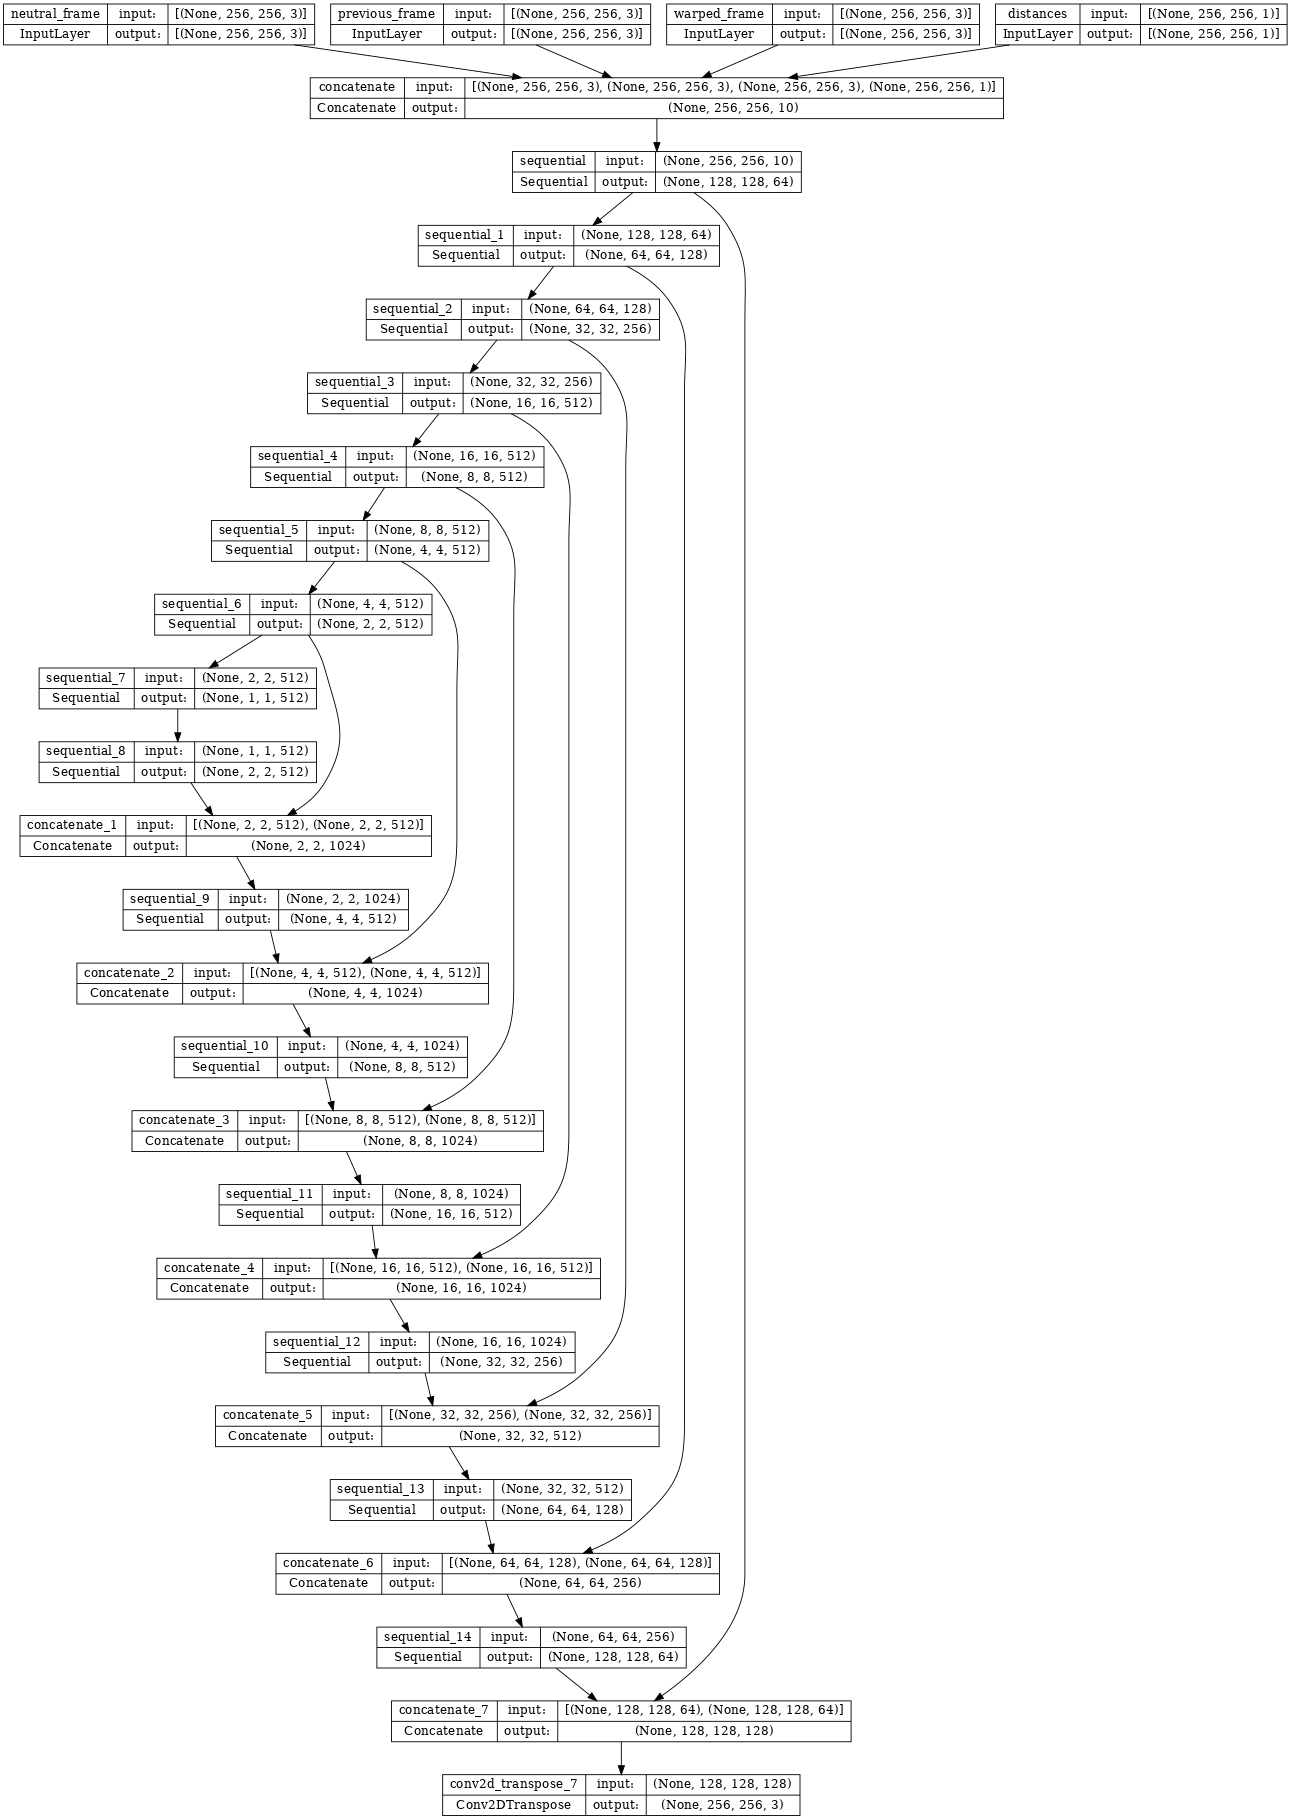

In [11]:
# The get_generator_model function  constructs a convolutional neural network designed to generate or modify facial expressions in images. This model is the core component for image synthesis.
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)  # Build the generator model 
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))  # Visualize model architecture


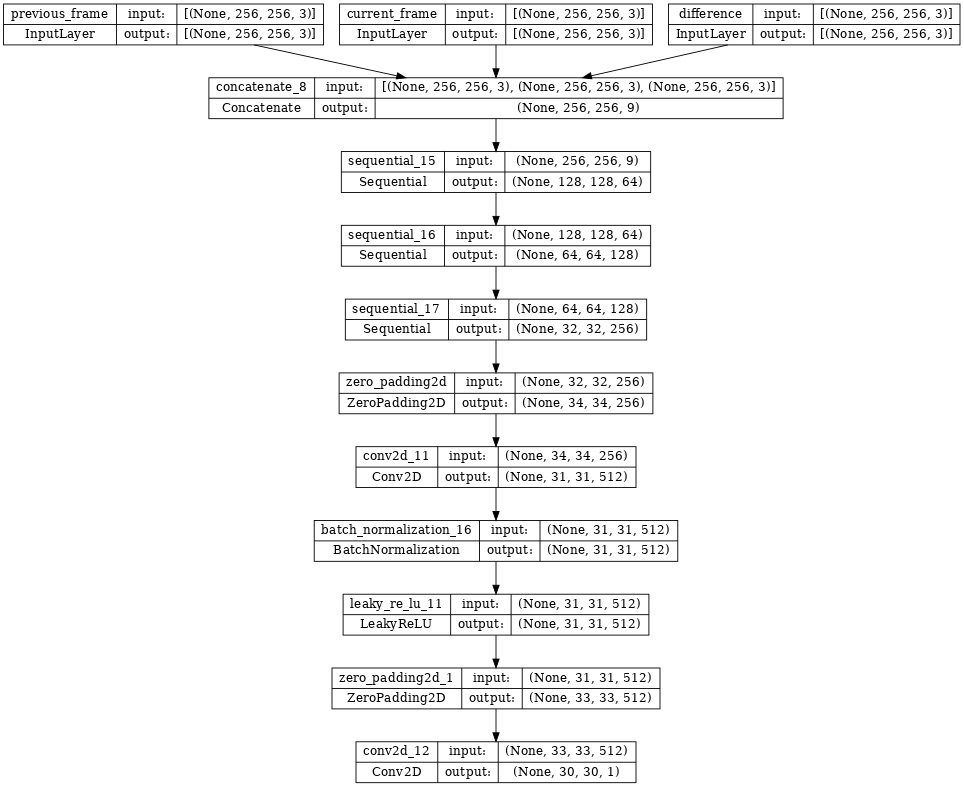

In [ ]:
# The get_discriminator_model function (which we defined earlier) constructs a convolutional neural network designed to distinguish between 'real' and 'fake' facial expressions/frames. This is used within a Generative Adversarial Network (GAN) setup.
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)  # Build the discriminator model
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))  # Create a visual representation of the model


In [13]:
generator_loss = GeneratorLoss(
    # target predicted loss
    target_predicted_function=TARGET_PREDICTED_LOSS,
    lambda_target_predicted=LAMBDA_TARGET_PREDICTED_LOSS,
    # coherence loss
    coherence_loss_function=COHERENCE_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    # landmarks loss
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    # landmarks coherence loss
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    # perceptual loss
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    # interpolation frames loss
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    # interpolation landmarks loss
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)

# Overall Purpose:

# This code instantiates a custom GeneratorLoss class. This class encapsulates the complex calculation of the total loss used to train your generator model. It combines multiple loss terms, each with a corresponding weight.

# Explanation:

# Custom Loss Class: The GeneratorLoss class likely defines methods to compute and combine the various loss components relevant to your facial expression system.

# Loss Functions (*_loss_function):  These parameters specify which loss functions (e.g., l1_loss we defined earlier) are used for different aspects of the training.

# Loss Weights (lambda_*):  These parameters control the relative importance of each loss term, allowing you to fine-tune the generator's behavior during training.

# Importance for Facial Expression Synthesis:

# Multi-faceted Optimization:  By considering losses related to image quality, temporal consistency, landmark accuracy, and potentially perceptual quality, this approach trains the generator to produce realistic, smoothly transitioning, and accurate facial expressions in videos.

# Hyperparameter Tuning: The loss weights provide a powerful mechanism for adjusting the model's priorities and output characteristics.

# Design Choices:

# Custom Class: Creating a GeneratorLoss class encapsulates the complexity of loss calculations, improving code modularity and readability.
# Potential Limitations:

# Hyperparameter Sensitivity:  Finding the optimal balance of loss weights often requires experimentation and can be sensitive to your dataset and task.

# Interpretability: the lambda is set to zero when we want to test the effect of some loss function on the final result.  THis wayit might become easier to isolate the primary causes behind certain undesirable behaviors of the generator model.
                    

80134624/80134624 [==============================] - 8s 0us/step


In [14]:
discriminator_loss = DiscriminatorLoss()

In [15]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)  # Instantiate Adam optimizer for the generator
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)  # Instantiate Adam optimizer for the discriminator
# Overall Purpose:

# This code block sets up optimizers for training the generator and discriminator models (likely used in a GAN setup). Optimizers are algorithms that update the model's weights during training to reduce its loss.

# Explanation:

# Adam Optimizer: Both lines of code use the Adam optimizer from the tf.keras.optimizers library. Adam is a widely used, adaptive optimizer known for its efficiency and robustness in many deep learning tasks.

# Parameters:

# 2e-4: This represents the learning rate (how big of a step to take in weight updates), 2e-4 is a common initial value.
# beta_1=0.5: This controls the exponential decay for the first-moment estimates (part of Adam’s adaptive mechanism), a default value of 0.5 often performs well.
# Importance for Facial Expression Synthesis

# Efficient Training: Adam allows for effective training of complex models with many parameters, like those often used for image generation.
# Gradient-Based Learning: Optimizers are core in deep learning, as they implement algorithms to adjust weights iteratively to improve performance based on the calculated loss.
# Design Choices:

# Optimizer Type: Adam is a popular choice due to its adaptability and generally good performance.
# Hyperparameters: The learning rate and decay parameters control how aggressively weights are updated, significantly impacting training.
# Potential Limitations:

# Hyperparameter Sensitivity: Finding optimal optimizer settings often requires experimentation, as they interact with the dataset, loss functions, and the model architecture itself.
# Convergence: Even with good optimizers, deep learning models may get stuck in local minima and not reach the global optimal solution.

In [16]:
BASE_DIR = OUTPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
# checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, directory=checkpoint_dir, max_to_keep=5)

## Training


In [17]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [18]:
def fit_deformed(train_dataset_generator, test_dataset_generator, steps):
    pbar = tqdm(range(steps), total=steps)  # Progress bar setup 
    for step in pbar:
        with tf.profiler.experimental.Trace('train', step_num=step, _r=1):  # Code profiling (if needed)

            if (step) % DISPLAY_EACH_STEPS == 0:
                clear_output(wait=True)      
                display(pbar.container)  # Update progress visually
                previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch_deformed()
                plot_results(samples_target, generated_frames)  # Display generated results

            with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
                gen_total_loss, disc_loss, gen_losses = train_dataset_generator.next_loss_deformed()  # Calculate losses
                generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)  # Calculate gradients for generator
                discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables) # Calculate gradients for discriminator          

                generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))  # Update generator weights 
                discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables)) # Update discriminator weights

                with summary_writer.as_default():  # Log training metrics
                    tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
                    tf.summary.scalar(f'disc_loss', disc_loss, step=step)
                    for name, value in gen_losses.items():
                        tf.summary.scalar(f'gen_{name}', value, step=step)

            if (step + 1) % SAVING_EACH_STEPS == 0:
                checkpoint_manager.save()  # Save model checkpoint (periodically) 
# Overall Purpose:

# This function implements the core training loop of your facial expression synthesis system, specifically focusing on the image deformation aspect. Let's break down what it does:

# Setup:

# Initializes a progress bar (pbar) using 'tqdm' for visually tracking training progress.
# Likely has a summary_writer defined globally for logging to TensorBoard.

# Training Iteration:

# Profiling (Optional): The tf.profiler.experimental.Trace context may be used for performance debugging.
# Visual Updates: Periodically displays the progress bar and sample generated images.
# Loss Calculation: Calls a function from your dataset generator to get losses for both generator and discriminator.
# Gradient Calculation: Uses tf.GradientTape to compute how the model weights should be changed with respect to the calculated losses.
# Weight Updates: Applies the calculated gradients to update both the generator and discriminator models using their respective optimizers.
# Logging: Writes training loss values to TensorBoard for analysis.
# Checkpointing: Saves the model's state periodically.
# Importance for Facial Expression Synthesis:

# Iterative Improvement: This function drives the learning process where the generator and discriminator (if it's a GAN setup) are iteratively updated to become better at their respective tasks.
# Monitoring and Analysis Progress visualization and logging are crucial for tracking how training proceeds and identifying potential issues.
# Design Choices:

# tqdm Progress Bar: Provides a user-friendly way to track training.
# TensorBoard Logging: Enables detailed analysis of training behavior.
# Checkpointing: Allows you to resume training from a saved point.
# Potential Limitations:

# Hyperparameter Sensitivity: The frequency of visual updates (DISPLAY_EACH_STEPS), checkpointing (SAVING_EACH_STEPS), and the training duration itself (steps) will greatly impact outcomes.

In [19]:
def fit_previous(train_dataset_generator, test_dataset_generator, steps):
    pbar = tqdm(range(steps), total=steps)  # Initialize a progress bar

    for step in pbar:
        with tf.profiler.experimental.Trace('train', step_num=step, _r=1):  # (Optional) Enable profiling

            if (step) % DISPLAY_EACH_STEPS == 0:
                clear_output(wait=True)  # Clear previous output (if any)
                display(pbar.container)  # Update the progress bar
                previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch() 
                plot_results(samples_target, generated_frames)  # Visualize results from the generator

            with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
                gen_total_loss, disc_loss, gen_losses = train_dataset_generator.next_loss()  # Calculate losses for gen. and disc.
                generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)  # Gradients for generator update
                discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables) # Gradients for discriminator update         

                generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))  # Update generator weights 
                discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables)) # Update discriminator weights

                with summary_writer.as_default():  # Log metrics 
                    tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
                    tf.summary.scalar(f'disc_loss', disc_loss, step=step)
                    for name, value in gen_losses.items():
                        tf.summary.scalar(f'gen_{name}', value, step=step)

            if (step + 1) % SAVING_EACH_STEPS == 0:
                checkpoint_manager.save()  # Save model checkpoint (periodically) 
# Overall Purpose:

# This function implements a core training loop for your facial expression synthesis model. It shares a very similar structure to the fit_deformed function, with the key difference likely being how the train_dataset_generator calculates losses.

# Explanation:

# Setup:

# Initializes a progress bar (pbar) for visualization.
# Likely has a globally defined summary_writer for logging.
# Training Iteration:

# Profiling (Optional): The tf.profiler.experimental.Trace context might be used for performance debugging.
# Visual Updates: Periodically displays the progress bar and sample generated images.
# Loss Calculation: Calls a function from your dataset generator to get losses for both generator and discriminator.
# Gradient Calculation: Uses tf.GradientTape to compute gradients.
# Weight Updates: Applies gradients to update model weights using their respective optimizers.
# Logging: Writes training loss values to TensorBoard.
# Checkpointing: Saves the model's state periodically.
# Importance for Facial Expression Synthesis

# Iterative Improvement: This drives the learning process where the models improve their ability to synthesize new facial expressions.
# Monitoring and Analysis: Progress visualization and logging are crucial for tracking how training proceeds and identifying potential issues.
# Design Choices:

# tqdm Progress Bar: Provides user-friendly tracking.
# TensorBoard Logging: Enables detailed training analysis.
# Checkpointing: Allows you to resume training if needed.
# Potential Limitations:

# Hyperparameter Sensitivity: The choice of DISPLAY_EACH_STEPS, SAVING_EACH_STEPS, and steps (total training duration) will significantly impact results.
# Dataset Generator: The core logic for how losses are calculated within the train_dataset_generator.next_loss() function will greatly influence the model's learning behavior.

In [20]:
if TRAIN:
    tf.profiler.experimental.start(str(log_dir))

2024-01-11 23:22:37.416907: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2024-01-11 23:22:37.416939: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2024-01-11 23:22:37.416975: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1694] Profiler found 1 GPUs


100%|#########9| 12735/12747 [8:16:39<00:17,  1.45s/it]

Ground Truth


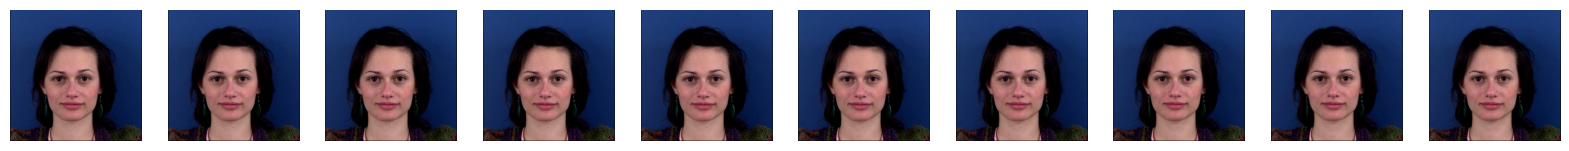

Predicted Sequence


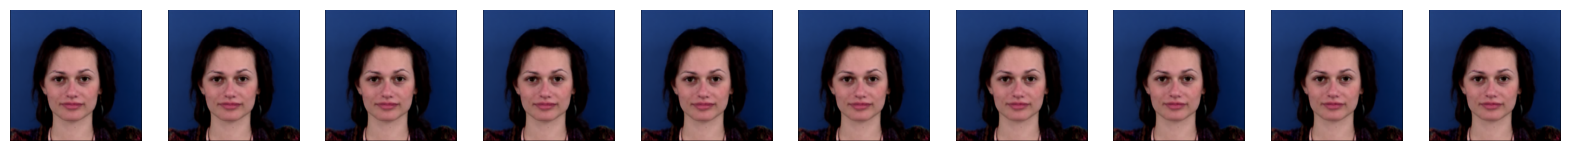

In [21]:
if TRAIN: 
    # Training Stage 1: Using Deformation-based Approach (fit_deformed)
    train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True, blend_deformation=BLEND_DEFORMATIONS)  
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS) 
    fit_deformed(train_generator, test_generator, steps=STEPS)  # Training with deformation-based approach 


100%|#########9| 12735/12747 [8:17:02<00:17,  1.43s/it]

Ground Truth


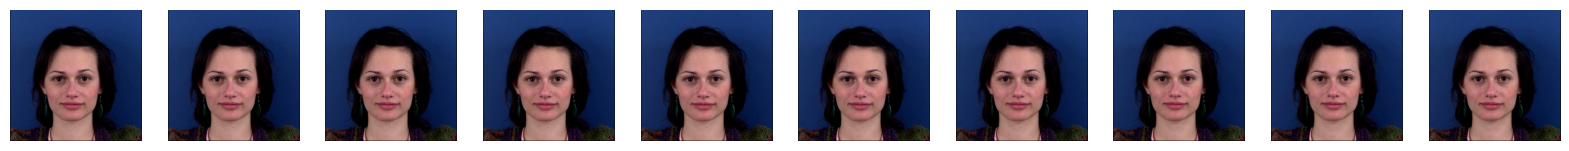

Predicted Sequence


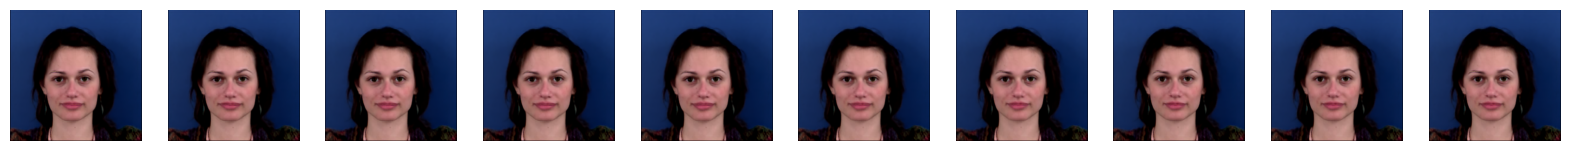

In [22]:
if TRAIN:
    # Training Stage 2: Using Previous Frame (fit_previous)
    train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True, blend_deformation=BLEND_DEFORMATIONS) 
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS) 
    fit_previous(train_generator, test_generator, steps=STEPS)  # Training with alternate approach 

# Overall Purpose:

# This code block implements a two-stage training workflow for your facial expression synthesis system.

# Explanation:

# Stage 1: Deformation-based Training (fit_deformed):

# This initial stage uses the fit_deformed function.
# The PreprocessedDataGenerator prepares batches where the target image is a warped version (using affine transformations) of the neutral frame, aiming to achieve the desired facial expression.
# This helps the model learn the basic deformations needed for expression synthesis.

# Stage 2: Previous Frame Training (fit_previous):

# After a specified number of steps (127475 steps - once per each frame of the training dataset), the training switches to the fit_previous function.
# The PreprocessedDataGenerator sets blend_deformation to False, indicating it won't provide warped neutral frames as targets anymore.
# Instead, it leverages the previously generated frame from the model's output as the target for the next step.
# it is also 127475 steps - once per each frame of the training dataset
# This allows the model to refine its output by considering the temporal coherence between frames in a video sequence.

# Importance for Facial Expression Synthesis:

# Staged Learning: This approach acknowledges that the model might initially benefit from more explicit guidance (deformation targets) before transitioning to learning from generated frames, leading to smoother transitions in video sequences.
# Design Choices:

# Two-Stage Training: This strategy allows the model to focus on core deformations first and then refine them considering temporal coherence.
# Data Generator Configuration: The PreprocessedDataGenerator likely adapts its behavior based on the training stage (blend_deformation flag).

# Potential Limitations:

# Hyperparameter Tuning: Finding the optimal number of steps for each stage (STEPS_DEFORMED and STEPS_PREVIOUS) might require experimentation.
# Error Accumulation: If the model's initial frames contain errors, they might propagate through the sequence during stage 2 training.


In [23]:
if TRAIN:    
    checkpoint_manager.save()

## Restore the latest checkpoint and test the network

In [24]:
!ls {checkpoint_dir}

checkpoint		      ckpt-507.index
ckpt-505.data-00000-of-00001  ckpt-508.data-00000-of-00001
ckpt-505.index		      ckpt-508.index
ckpt-506.data-00000-of-00001  ckpt-509.data-00000-of-00001
ckpt-506.index		      ckpt-509.index
ckpt-507.data-00000-of-00001


In [25]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [26]:
# test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)
# for i in range(0,10):
#   generated_frames, samples_target = test_generator.generate_next_batch()
#   clear_output(wait=True)
#   plot_results(samples_target, generated_frames)

In [27]:
if SAVE_GIFS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER, blend_deformation=BLEND_DEFORMATIONS)
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                test_generator.save_next_video()
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break

In [28]:
if SAVE_GIFS_SIMILAR:
    OUTPUT_MEDIA_SIMILAR_FOLDER = OUTPUT_PATH / id_string / 'media_similar'
    OUTPUT_MEDIA_SIMILAR_FOLDER.mkdir(parents=True, exist_ok=True)
    for expression_name in FACIAL_EXPRESSION_NAMES:
        test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_SIMILAR_FOLDER, blend_deformation=BLEND_DEFORMATIONS, search_similar=True, expression_name=expression_name)
        with tqdm(total=N_TESTING_FRAMES) as pbar:
            while True:
                try:
                    clear_output(wait=True)
                    test_generator.save_next_video()
                    pbar.update(BATCH_SIZE)
                except StopIteration:
                    break

In [29]:
if SAVE_GIFS_LAPIS_TEST:
    OUTPUT_MEDIA_LAPIS_FOLDER = OUTPUT_PATH / id_string / 'media_lapis'
    OUTPUT_MEDIA_LAPIS_FOLDER.mkdir(parents=True, exist_ok=True)
    for expression_name in FACIAL_EXPRESSION_NAMES:
        test_generator = PreprocessedDataGenerator(LAPIS_TEST_PATHS, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_LAPIS_FOLDER, blend_deformation=BLEND_DEFORMATIONS, search_similar=True, similar_source_videos_path=test_paths, expression_name=expression_name)
        with tqdm(total=N_TESTING_FRAMES) as pbar:
            while True:
                try:
                    clear_output(wait=True)
                    test_generator.save_next_video()
                    pbar.update(BATCH_SIZE)
                except StopIteration:
                    break

In [30]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    """Calculates Average Cumulative Displacement (ACD) for a given video sequence.

    Args:
        frames (np.ndarray): A numpy array of shape (num_frames, height, width, channels) representing video frames.

    Returns:
        float: The ACD metric value.
    """

    N = np.multiply.reduce(frames.shape[1:-1])  # Number of pixels (ignoring channels) 
    res = np.mean(
            np.linalg.norm(
                np.diff(
                    np.einsum('ijkl->il', frames),  # Reshape for efficient difference calculation
                axis=0) / N,  # Calculate pixel-wise displacements between frames, normalize
            axis=1)  # Average the displacements across all pixels
        )

    return res

def compare_acd(target_sequence, generated_output):
    """Compares ACD between a target video sequence and a generated one.

    Args:
        target_sequence (np.ndarray):  The ground truth video sequence.
        generated_output (np.ndarray):  The video sequence produced by the model.

    Returns: 
        float: The absolute difference between the ACD values of the two sequences.
    """

    return np.abs(acd(target_sequence) - acd(generated_output)) 

# Overall Purpose:

# These functions implement the Average Cumulative Displacement (ACD) metric and provide a way to compare it between real and generated video sequences. ACD aims to measure the motion smoothness and temporal coherence in videos.

# Explanation:

# acd Function:

# Calculates Pixel-wise Differences: Computes the difference in position for each pixel between consecutive frames.
# Normalizes Differences: Divides the displacements by the number of pixels to make the metric scale-independent.
# Averages over Frames and Pixels: Averages the normalized displacements across all frames and pixels, giving a single value representing the degree of motion in the video.
# compare_acd Function:

# Calculates the absolute difference between the ACD values of a target_sequence and generated_output.
# Importance for Facial Expression Synthesis

# Temporal Coherence Evaluation: ACD helps measure how smoothly facial expressions transition across frames in a generated video. Lower ACD values generally suggest greater temporal consistency.
# Design Choices:

# Pixel-based: ACD focuses on low-level pixel motion, which might capture subtle artifacts or noise in generated videos.
# Difference Calculation: np.einsum likely improves efficiency by optimizing array operations.
# Potential Limitations:

# Sensitivity to Noise: ACD can be sensitive to subtle noise present in video frames.
# Global Motion: ACD primarily captures the overall amount of motion but might not distinguish between meaningful changes in expression vs. undesired artifacts.


In [31]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size)
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                generated_frames, current_frames = test_generator.generate_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

# Overall Purpose:

# These functions provide a comprehensive evaluation framework for your facial expression synthesis system comapring the genreated frames with expected frames (from the dataset).

# Importance for Facial Expression Synthesis

# Quantitative Evaluation: These metrics provide numerical scores that help track progress, compare different models or training strategies, and identify areas for improvement.
# Multi-faceted Analysis: By using multiple metrics (SSIM, PSNR, FVD, etc.), you gain diverse insights into the strengths and weaknesses of your generated videos.

# Design Choices:

# Diverse Metrics: The code includes both traditional image quality metrics (MSE, L1) and more advanced, perception-focused metrics (FID, FVD).
# Data Generator Usage: The compute_scores leverages a data generator to efficiently process batches from your test dataset.
# Progress Tracking: The use of tqdm and intermediate result saving enables monitoring of the evaluation process.
# Potential Limitations:

# Metric Relevance: Some metrics may be more important than others depending on your specific goals.





In [32]:
if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)
    scores_path = f"{log_dir}/metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

42060it [1:06:53,  2.42it/s]

SSIM     0.813181
PSNR    27.444567
MSE      0.009169
L1       0.049224
ACD      0.000408
dtype: float64
SSIM    0.053781
PSNR    2.720654
MSE     0.009974
L1      0.018297
ACD     0.000307
dtype: float64


In [33]:
if TEST:
    print(df)

          SSIM       PSNR       MSE        L1       ACD
0     0.874007  30.843378  0.003175  0.033716  0.000363
1     0.863389  29.980551  0.003972  0.036434  0.000213
2     0.832727  26.463354  0.008977  0.048044  0.000461
3     0.819836  25.703175  0.010570  0.051120  0.000314
4     0.818429  25.795185  0.010362  0.050538  0.000183
...        ...        ...       ...       ...       ...
4201  0.824115  28.974588  0.004888  0.046820  0.000185
4202  0.835875  29.981831  0.003938  0.041265  0.000841
4203  0.830841  29.852835  0.004043  0.040269  0.001119
4204  0.827166  29.732798  0.004133  0.041088  0.001421
4205  0.861991  30.322906  0.003599  0.036835  0.000039

[4206 rows x 5 columns]


In [34]:
if TEST:
    print(df.mean())

SSIM     0.813181
PSNR    27.444567
MSE      0.009169
L1       0.049224
ACD      0.000408
dtype: float64


In [35]:
if TEST:
    print(df.std())

SSIM    0.053781
PSNR    2.720654
MSE     0.009974
L1      0.018297
ACD     0.000307
dtype: float64


# coherence measures

In [36]:
def compute_scores_diff():
    """Calculates metrics for 'diff' frames (differences between consecutive video frames).
       Iterates through test data in batches and saves results. """

    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:  # Initialize progress bar

        while True:
            try:
                clear_output(wait=True)  # Clear previous output (if any)
                display(pbar.container)  # Update progress bar visually
                df = pd.DataFrame(scores)  # Create a DataFrame to store metrics
                df.to_csv(f"{log_dir}/diff_metrics.csv")  # Save metrics to CSV
                print(df.mean())  # Print mean for monitoring
                print(df.std())  # Print standard deviation for monitoring

                _, generated_frames, current_frames = test_generator.generate_diff_batch()  # Get a batch of 'diff' frames 
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)  # Calculate metrics
                scores.append(s)  # Store metrics for this batch
                pbar.update(BATCH_SIZE)  # Update the progress bar

            except StopIteration: 
                break  # Exit the loop when the test generator is exhausted
    return scores 

if TEST:
    # Initialize test data generator
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)

    scores_path = f"{log_dir}/diff_metrics.csv"  
    scores = compute_scores_diff()  # Calculate and store the 'diff' metrics
    df = pd.DataFrame(scores)
    df.to_csv(scores_path) 

# Overall Purpose

# This code seems designed to calculate and store image quality metrics specifically focusing on differences between frames in your test video sequences. Let's break down why this might be interesting:

# Explanation

# Focus on diff Frames: The key is the test_generator.generate_diff_batch() function. Your PreprocessedDataGenerator likely has a mode where it provides consecutive video frames and their difference as the target.

# Analyzing Temporal Changes: By evaluating metrics on these 'diff' frames, you likely gain insights into your model's ability to generate smooth and consistent changes in facial expressions.

# Importance for Facial Expression Synthesis

# Temporal Coherence Evaluation: Metrics on 'diff' frames help assess if the model produces jerky transitions or artifacts between frames in the generated videos.
# Implicit Motion Analysis: Although not directly measuring motion, changes between frames are strongly associated with it.
# Design Choices

# Custom generate_diff_batch: This function highlights pre-processing choices. Your dataset might include the differences between frames for the purpose of this evaluation.
# Data Generator: Using your PreprocessedDataGenerator streamlines the process.
# Potential Limitations

# Analyzing differences between frames might be insufficient to fully evaluate temporal coherence. More direct motion-focused metrics would be a useful addition.


42060it [1:09:16,  2.42it/s]

SSIM     0.937044
PSNR    40.160164
MSE      0.001555
L1       0.012213
ACD      0.000410
dtype: float64
SSIM    0.036175
PSNR    3.229135
MSE     0.003850
L1      0.008447
ACD     0.000313
dtype: float64


In [37]:
if TEST:
    print(df.mean())

SSIM     0.937044
PSNR    40.160164
MSE      0.001555
L1       0.012213
ACD      0.000410
dtype: float64


In [38]:
if TEST:
    print(df.std())

SSIM    0.036175
PSNR    3.229135
MSE     0.003850
L1      0.008447
ACD     0.000313
dtype: float64


# Plot some images

In [39]:
if PLOT:
  test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)
  for i in range(0,10):
    clear_output(wait=True)
    test_generator.next_plot()

# Save videos gifs

# Test per video

In [40]:
def compute_scores_video():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_next_video() # TODO: blended frames
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [41]:
if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)
    scores_path = f"{log_dir}/video_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_video()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [42]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [43]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())

In [44]:
def compute_video_scores_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_diff_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_diff_video() # TODO: blended frames
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)
    scores_path = f"{log_dir}/video_diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_video_scores_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [45]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [46]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())

# Test deformation

In [47]:
def compute_deformation_scores():
    """Calculates metrics for 'deformed' frames (likely warped versions of originals) and saves results."""

    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:  # Initialize progress bar
        while True:
            try:
                clear_output(wait=True)  # Clear previous output for better display
                display(pbar.container)  # Update progress bar
                df = pd.DataFrame(scores)  # Create DataFrame to store metrics
                df.to_csv(f"{log_dir}/deformed_metrics.csv")  # Save metrics to CSV
                print(df.mean()) 
                print(df.std()) 

                deformed_frames, current_frames = test_generator.deformed_next_batch()  # Get a batch of 'deformed' frames
                s = evaluate_metrics(current_frames, deformed_frames, batch_size=BATCH_SIZE)  # Calculate metrics
                scores.append(s) # Store metrics results 
                pbar.update(BATCH_SIZE)  # Update progress

            except StopIteration:  
                break  # Exit loop when the test generator is exhausted
    return scores 

if TEST_DEFORMATIONS:
    # Initialize test data generator (assuming PreprocessedDataGenerator class)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)

    scores_path = f"{log_dir}/deformed_metrics.csv"  
    scores = compute_deformation_scores()  # Calculate and store the 'deformed' metrics
    df = pd.DataFrame(scores)
    df.to_csv(scores_path) 

# Overall Purpose:

# This code block aims to provide metrics specifically focusing on the 'deformed' frames produced during an intermediate stage of your facial expression synthesis process.

# Explanation:

# Focus on Deformations: The test_generator.deformed_next_batch() function suggests your PreprocessedDataGenerator can provide 'deformed' frames, likely warped versions of the input images.

# Evaluating Deformation Quality: By comparing these deformed frames with the original ones (presumably the desired target), you're assessing how well your model learns to introduce the necessary deformations for achieving target expressions.

# Importance for Facial Expression Synthesis

# Analyzing Intermediate Results: This helps isolate potential errors or weaknesses in the deformation component of your system. This is useful if you have a multi-stage training setup.
# Debugging: Good scores here would suggest the model has learned the basic transformations needed, allowing you to focus on other aspects like refining outputs.
# Design Choices

# Custom deformed_next_batch: This function indicates the likely use of warping or image manipulation techniques in the generation process.
# Potential Limitations:

# Indirect Assessment: Evaluating only deformations may not directly translate to the quality of final synthesized expressions.


In [48]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [49]:
if TEST_DEFORMATIONS:
    print(df.std())

In [50]:
def compute_scores_deformed_diff():
    """
    Calculates metrics focusing on the differences between 'deformed' frames and their corresponding ground truth differences.
    This helps analyze the quality of the deformations applied by the model.
    """

    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:  # Initialize progress bar
        while True:
            try:
                clear_output(wait=True)  # Clear previous output
                display(pbar.container)  # Update progress bar
                df = pd.DataFrame(scores)    # Create DataFrame to store metrics
                df.to_csv(f"{log_dir}/deformed_diff_metrics.csv")  # Save metrics 
                print(df.mean())  
                print(df.std()) 

                current_diffs, deformed_diffs = test_generator.get_deformed_diff_batch()  # Get a batch of 'deformed' differences
                s = evaluate_metrics(current_diffs, deformed_diffs, batch_size=BATCH_SIZE)  # Calculate metrics
                scores.append(s) # Store metrics results 
                pbar.update(BATCH_SIZE)  # Update progress

            except StopIteration:  
                break  # Exit loop when the test generator is exhausted
    return scores 

if TEST_DEFORMATIONS:
    # Initialize test data generator (assuming PreprocessedDataGenerator class)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=BLEND_DEFORMATIONS)

    scores_path = f"{log_dir}/deformed_diff_metrics.csv"  
    scores = compute_scores_deformed_diff()  # Calculate and store the 'deformed' metrics
    df = pd.DataFrame(scores)
    df.to_csv(scores_path) 

# Overall Purpose:

# This code block aims to provide a more nuanced evaluation of the deformation process in your facial expression system. It focuses on how well the model-generated deformations match the desired changes between consecutive frames.

# Explanation:

# Focus on Difference of Deformations: The key is the test_generator.get_deformed_diff_batch(). It is computed differences between consecutive frames (ground truth) and your PreprocessedDataGenerator can provide the model's corresponding deformed frame differences.

# Analyzing Deformation Accuracy: Comparing the model's deformed differences to the ground truth ones highlights how accurately it learns to modify facial features.

# Importance for Facial Expression Synthesis

# Targeted Debugging: If your deformations are the primary way to alter expressions, these metrics directly pinpoint whether the changes made are correct.
# Potential for Refinement: Good scores here might indicate focusing on later stages of the process for greater improvement in overall output.

# Design Choices

# Custom get_deformed_diff_batch: This function highlights the potentially complex pre-processing or calculation of frame differences within your system.
# Potential Limitations

# Assumes Deformations Are Primary: This evaluation is most meaningful if your system primarily relies on deformations to generate new expressions.

In [51]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [52]:
if TEST_DEFORMATIONS:
    print(df.std())

# Test blended deformations

In [53]:
def compute_deformation_scores():
    """
    Calculates metrics for 'blended_deformations' (likely blends generated output with the original frame).
    This aids in evaluating how well blended deformations contribute to final expression synthesis.
    """

    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:  # Initialize progress bar
        while True:
            try:
                clear_output(wait=True)  # Clear previous output for visual clarity
                display(pbar.container)  # Update the progress bar
                df = pd.DataFrame(scores)  # Create a DataFrame to store metrics
                df.to_csv(f"{log_dir}/blended_deformations_metrics.csv")  # Save metrics to CSV
                print(df.mean())  # Print mean for monitoring purposes
                print(df.std())  # Print standard deviation 

                deformed_frames, current_frames = test_generator.blended_next_batch()  # Get a batch of 'blended deformations'
                s = evaluate_metrics(current_frames, deformed_frames, batch_size=BATCH_SIZE)  # Calculate metrics
                scores.append(s) # Store metric results 
                pbar.update(BATCH_SIZE)  # Update progress

            except StopIteration:  
                break  # Exit loop when the test generator is exhausted
    return scores 

if TEST_DEFORMATIONS:
    # Initialize test data generator (assuming PreprocessedDataGenerator class)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

    scores_path = f"{log_dir}/blended_deformations_metrics.csv"  
    scores = compute_deformation_scores()  # Calculate and store the 'blended' metrics
    df = pd.DataFrame(scores)
    df.to_csv(scores_path) 


# Overall Purpose:

# This code block evaluates the impact of blending deformed frames with the original input within your facial expression synthesis system.

# Explanation:

# Focus on Blending: The test_generator.blended_next_batch() function indicates that your PreprocessedDataGenerator likely has a mode where it provides the output of a blending operation, which combines a deformed version of the face with the original input frame.

# Evaluating Blending Effectiveness: By comparing these blended frames with their corresponding ground truth, you're assessing how well the blending process helps in achieving smoother or more realistic transitions.

# Importance for Facial Expression Synthesis

# Refinement Analysis: Blending is often used to mitigate artifacts from deformation. These metrics help analyze if it improves the final output quality.
# Design Choices

# Custom blended_next_batch: This function highlights the choice to use blending likely to improve the realism of the generated results.
# Potential Limitations

# Dependent on Deformation Quality: If the initial deformations are poor, blending might not fully address the issue, limiting the effectiveness of this evaluation.


In [54]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [55]:
if TEST_DEFORMATIONS:
    print(df.std())

In [56]:
def compute_scores_deformed_diff():
    """
    Calculates metrics focusing on the differences between frames that have undergone deformation and blending.
    This helps analyze whether the blending process improves the smoothness of transitions in the generated expressions.
    """

    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:  # Initialize progress bar
        while True:
            try:
                clear_output(wait=True)  # Clear previous output
                display(pbar.container)  # Update progress bar
                df = pd.DataFrame(scores)    # Create DataFrame for storing metrics
                df.to_csv(f"{log_dir}/blended_deformations_diff_metrics.csv")  # Save metrics 
                print(df.mean())  
                print(df.std()) 

                current_diffs, deformed_diffs = test_generator.blended_diff_batch()  # Get a batch of 'blended' differences
                s = evaluate_metrics(current_diffs, deformed_diffs, batch_size=BATCH_SIZE)  # Calculate metrics
                scores.append(s)     # Store metrics results 
                pbar.update(BATCH_SIZE)  # Update progress

            except StopIteration:  
                break  # Exit loop when the test generator is exhausted
    return scores 

if TEST_DEFORMATIONS:
    # Initialize test data generator (assuming PreprocessedDataGenerator class)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=True)

    scores_path = f"{log_dir}/blended_deformations_diff_metrics.csv"  
    scores = compute_scores_deformed_diff()  # Calculate and store the 'blended diff' metrics
    df = pd.DataFrame(scores)
    df.to_csv(scores_path) 

# Overall Purpose:

# This code block aims to provide a nuanced evaluation of how blending deformed frames impacts the smoothness of transitions in your synthesized facial expressions.

# Explanation:

# Focus on Blended Difference: The key is the test_generator.blended_diff_batch(). This suggests your dataset might include pre-computed differences between consecutive frames and that your PreprocessedDataGenerator can provide differences between the model's blended deformations and their corresponding ground truth.

# Analyzing Blending's Effect on Temporal Coherence:  Comparing the model's blended deformed differences to  ground-truth differences highlights how effectively blending contributes to achieving smoother changes in expressions.

# Importance for Facial Expression Synthesis

# Evaluating Blending for Smoother Transitions: Blending deformed frames is often used to improve the temporal consistency of generated videos. These metrics directly assess that aspect.
# Design Choices

# Custom blended_diff_batch: This function highlights the choice to potentially calculate and store complex pre-processed data for this evaluation.
# Potential Limitations

# Assumes Blending Helps: This analysis is most valuable if you generally expect blending to improve temporal smoothness. If blending introduces its own artifacts, the metrics might become less insightful.

In [57]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [58]:
if TEST_DEFORMATIONS:
    print(df.std())